# 🎮 Análisis Exploratorio de Ventas de Videojuegos 
Este notebook realiza la carga, limpieza y análisis exploratorio inicial del dataset `VideoGamesSales.csv`.

# 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carga de datos

In [3]:
dfVideoJuegos = pd.read_csv("D:\Desktop\DAM2\DAM2_PythonAI\RA3-DataSets\VideoGamesSales.csv", sep=";")

print("=== Primeras filas del dataset ===")
print(dfVideoJuegos.head())

# Convertir columnas de fechas
dfVideoJuegos["release_date"] = pd.to_datetime(dfVideoJuegos["release_date"], dayfirst=True, errors="coerce")
dfVideoJuegos["last_update"] = pd.to_datetime(dfVideoJuegos["last_update"], dayfirst=True, errors="coerce")

print("\n=== Dataset con fechas convertidas ===")
print(dfVideoJuegos.head())

=== Primeras filas del dataset ===
                                             img                        title  \
0  /games/boxart/full_6510540AmericaFrontccc.jpg           Grand Theft Auto V   
1  /games/boxart/full_5563178AmericaFrontccc.jpg           Grand Theft Auto V   
2                    /games/boxart/827563ccc.jpg  Grand Theft Auto: Vice City   
3  /games/boxart/full_9218923AmericaFrontccc.jpg           Grand Theft Auto V   
4  /games/boxart/full_4990510AmericaFrontccc.jpg    Call of Duty: Black Ops 3   

  console    genre       publisher       developer  critic_score  total_sales  \
0     PS3   Action  Rockstar Games  Rockstar North           9.4        20.32   
1     PS4   Action  Rockstar Games  Rockstar North           9.7        19.39   
2     PS2   Action  Rockstar Games  Rockstar North           9.6        16.15   
3    X360   Action  Rockstar Games  Rockstar North           NaN        15.86   
4     PS4  Shooter      Activision        Treyarch           8.1        1

# 3. Limpieza y preparación de datos

In [4]:
# 3. Conteo de valores nulos
print("=== Valores nulos por columna ===")
print(dfVideoJuegos.isna().sum())

# 4. Rellenar nulos en critic_score y total_sales
dfVideoJuegos.fillna({'critic_score': 0, 'total_sales': 0}, inplace=True)

# 5. Corregir formato de total_sales (coma → punto → float)
dfVideoJuegos['total_sales'] = (
    dfVideoJuegos['total_sales'].astype(str).str.replace(',', '.').astype(float)
)

print("\n=== Conteo de nulos después de `fillna` ===")
print(dfVideoJuegos[['critic_score', 'total_sales']].isna().sum())

=== Valores nulos por columna ===
img                 0
title               0
console            63
genre              63
publisher          63
developer          80
critic_score    57338
total_sales     45133
na_sales        51384
jp_sales        57326
pal_sales       51198
other_sales     48895
release_date     7112
last_update     46191
dtype: int64

=== Conteo de nulos después de `fillna` ===
critic_score    0
total_sales     0
dtype: int64


## 3.1 Creación de Features (Ventas Regionales y Edad del Juego)

Se calculan la suma total de ventas regionales para comparación y la edad del juego en días.

In [5]:
# 6. Crear columna de ventas regionales sumadas
dfVideoJuegos['regional_sales_sum'] = (
    dfVideoJuegos['na_sales'] +
    dfVideoJuegos['jp_sales'] +
    dfVideoJuegos['pal_sales'] +
    dfVideoJuegos['other_sales']
)

print("=== Comparación total_sales vs regional_sales_sum ===")
print(dfVideoJuegos[['title', 'total_sales', 'regional_sales_sum']].head(10))

# 7. Porcentaje de ventas en Norteamérica
dfVideoJuegos['sales_na_pct'] = dfVideoJuegos['na_sales'] / dfVideoJuegos['total_sales']

print("\n=== Ventas en Norteamérica (primeras filas) ===")
print(dfVideoJuegos[['title', 'na_sales', 'total_sales', 'sales_na_pct']].head(10))

# 8. Edad del juego desde lanzamiento hasta última actualización
dfVideoJuegos['age_days_since_release'] = (
    dfVideoJuegos['last_update'] - dfVideoJuegos['release_date']
).dt.days

print("\n=== Edad del juego en días (10 filas al azar) ===")
# Se corrige el .sample por .sample(10) para una salida útil en un notebook
print(dfVideoJuegos[['title', 'release_date', 'last_update', 'age_days_since_release']].sample(10))

=== Comparación total_sales vs regional_sales_sum ===
                            title  total_sales  regional_sales_sum
0              Grand Theft Auto V        20.32               20.33
1              Grand Theft Auto V        19.39               19.39
2     Grand Theft Auto: Vice City        16.15               16.15
3              Grand Theft Auto V        15.86               15.87
4       Call of Duty: Black Ops 3        15.09               15.08
5  Call of Duty: Modern Warfare 3        14.82               14.82
6         Call of Duty: Black Ops        14.74               14.74
7           Red Dead Redemption 2        13.94               13.94
8      Call of Duty: Black Ops II        13.86               13.86
9      Call of Duty: Black Ops II        13.80               13.80

=== Ventas en Norteamérica (primeras filas) ===
                            title  na_sales  total_sales  sales_na_pct
0              Grand Theft Auto V      6.37        20.32      0.313484
1              Gra

## 4. Estadísticas Globales

Cálculo de la media, mediana, desviación estándar, y conteo de elementos únicos para entender la distribución de los datos.

In [6]:
numeric_cols_for_stats = ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
for col in numeric_cols_for_stats:
    # Convertir forzosamente a numérico.
    dfVideoJuegos[col] = pd.to_numeric(dfVideoJuegos[col], errors='coerce')


# 4.1 Asegurar el tipo numérico para todas las columnas de cálculo

In [7]:


# Calcular estadísticos
estadisticos = dfVideoJuegos[numeric_cols_for_stats].describe().loc[['mean', '50%', 'std', 'min', 'max']]
estadisticos.rename(index={
    '50%': 'mediana', 
    'std': 'desviacion_estandar', 
    'mean': 'media', 
    'min': 'minimo', 
    'max': 'maximo'
}, inplace=True)

# Contar elementos
total_videojuegos = len(dfVideoJuegos)
consolas_distintas = dfVideoJuegos['console'].nunique()
generos_distintos = dfVideoJuegos['genre'].nunique()


# Mostrar resultados
print("\n--- RESULTADOS DEL ANÁLISIS EXPLORATORIO ---")
print("\nEstadísticas Globales:")
print(estadisticos)
print("\nConteo de Elementos:")
print(f"Total de Videojuegos: {total_videojuegos}")
print(f"Total de Consolas Distintas: {consolas_distintas}")
print(f"Total de Géneros Distintos: {generos_distintos}")


--- RESULTADOS DEL ANÁLISIS EXPLORATORIO ---

Estadísticas Globales:
                     critic_score  total_sales  na_sales  jp_sales  pal_sales  \
media                    0.753220     0.103162  0.264831  0.102617   0.149530   
mediana                  0.000000     0.000000  0.120000  0.040000   0.040000   
desviacion_estandar      2.256713     0.467003  0.494863  0.169182   0.392735   
minimo                   0.000000     0.000000  0.000000  0.000000   0.000000   
maximo                  10.000000    20.320000  9.760000  2.130000   9.850000   

                     other_sales  
media                   0.043054  
mediana                 0.010000  
desviacion_estandar     0.126671  
minimo                  0.000000  
maximo                  3.120000  

Conteo de Elementos:
Total de Videojuegos: 64016
Total de Consolas Distintas: 81
Total de Géneros Distintos: 20


# 4.2 Distribución por consola/plataforma 

In [8]:
# 1. Agrupar por 'console' y calcular métricas
df_consolas_stats = dfVideoJuegos.groupby('console').agg(
    # Calcular el número de juegos (contando el título o cualquier columna no nula)
    num_juegos=('title', 'count'),
    
    # Calcular las ventas totales
    ventas_totales=('total_sales', 'sum'),
    
    # Calcular la puntuación media de la crítica
    puntuacion_media_critica=('critic_score', 'mean')
)

# 2. Ordenar consolas de mayor a menor según ventas totales
df_consolas_stats = df_consolas_stats.sort_values(
    by='ventas_totales', 
    ascending=False
)

# 3. Formatear la salida para una mejor lectura
# Redondear las puntuaciones y las ventas para mostrar solo 2 decimales
df_consolas_stats['ventas_totales'] = df_consolas_stats['ventas_totales'].round(2)
df_consolas_stats['puntuacion_media_critica'] = df_consolas_stats['puntuacion_media_critica'].round(2)

# 4. Mostrar el DataFrame resultante
print("=== Estadísticas de Videojuegos Agrupadas por Consola ===")
print(df_consolas_stats)

=== Estadísticas de Videojuegos Agrupadas por Consola ===
         num_juegos  ventas_totales  puntuacion_media_critica
console                                                      
PS2            3563         1027.74                      0.80
X360           1728          859.54                      2.66
PS3            1899          839.40                      2.01
PS             2707          546.25                      0.71
PS4            2866          539.74                      0.40
...             ...             ...                       ...
TG16              3            0.00                      0.00
XS              620            0.00                      0.08
ZXS              19            0.00                      0.00
iOS             155            0.00                      0.24
iQue             17            0.00                      0.00

[81 rows x 3 columns]


## 4.2 Análisis de Resultados por Consola 🎮

Tras agrupar y ordenar los datos por ventas totales, podemos analizar la dominancia en el mercado y la calidad percibida:

---

### ¿Qué consolas dominan las ventas?

* La consola que domina las ventas totales es la **PS2** (PlayStation 2), con aproximadamente **1,027.74 millones** de unidades vendidas.
* El mercado está dominado por las consolas de **Sony** y **Microsoft** de las generaciones clave, siendo el Top 3: **PS2**, **X360** (Xbox 360) y **PS3** (PlayStation 3).
* Estas tres plataformas tuvieron el mayor impacto económico en el conjunto de datos.

### ¿Qué consola tiene la mejor puntuación media crítica?

* La consola con la puntuación media de crítica más alta es **NGage** (4.80).
* Sin embargo, este resultado debe interpretarse con cautela, ya que **NGage** tiene un número de juegos muy reducido (61).
* Entre las consolas con alto volumen de ventas, **X360** (2.66) y **PS3** (2.01) muestran puntuaciones medias sólidas, lo que sugiere una alta calidad percibida en sus catálogos.

# 4.3 Análisis por género

In [9]:
# 1. Agrupar por 'genre' y calcular métricas
df_generos_stats = dfVideoJuegos.groupby('genre').agg(
    # Calcular el número de juegos
    num_juegos=('title', 'count'),
    
    # Calcular las ventas totales
    ventas_totales=('total_sales', 'sum'),
    
    # Calcular la puntuación media de la crítica
    puntuacion_media_critica=('critic_score', 'mean')
)

# 2. Ordenar géneros de mayor a menor según ventas totales
df_generos_stats = df_generos_stats.sort_values(
    by='ventas_totales', 
    ascending=False
)

# 3. Formatear la salida
df_generos_stats['ventas_totales'] = df_generos_stats['ventas_totales'].round(2)
df_generos_stats['puntuacion_media_critica'] = df_generos_stats['puntuacion_media_critica'].round(2)

# 4. Mostrar el DataFrame resultante
print("=== Estadísticas de Videojuegos Agrupadas por Género (Top 5) ===")
print(df_generos_stats.head())

print("\n=== Género con la Puntuación Media de Crítica más Alta ===")
print(df_generos_stats.loc[df_generos_stats['puntuacion_media_critica'].idxmax()])

=== Estadísticas de Videojuegos Agrupadas por Género (Top 5) ===
         num_juegos  ventas_totales  puntuacion_media_critica
genre                                                        
Sports         5586         1187.51                      0.90
Action         8555         1125.79                      0.82
Shooter        5410          995.50                      1.18
Misc           9304          557.79                      0.25
Racing         3425          525.75                      1.08

=== Género con la Puntuación Media de Crítica más Alta ===
num_juegos                  5410.00
ventas_totales               995.50
puntuacion_media_critica       1.18
Name: Shooter, dtype: float64


## 4.4 Análisis de Ventas por Región

Esta sección calcula la proporción de ventas por región (`na_sales`, `jp_sales`, `pal_sales`, `other_sales`) respecto al total global (`total_sales`) para entender la distribución geográfica.

In [10]:
# Columnas de ventas regionales
regional_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']

# 1. Calcular las ventas totales por región
ventas_regionales_sum = dfVideoJuegos[regional_cols].sum()

# 2. Calcular las ventas totales globales (ya tienes la columna 'total_sales' limpia)
ventas_globales_sum = dfVideoJuegos['total_sales'].sum()

# 3. Calcular las proporciones
proporciones_regionales = (ventas_regionales_sum / ventas_globales_sum * 100).round(2)

print("=== Proporción de Ventas Globales por Región ===")
print(proporciones_regionales.to_frame(name='Proporción (%)'))

=== Proporción de Ventas Globales por Región ===
             Proporción (%)
na_sales              50.66
jp_sales              10.40
pal_sales             29.02
other_sales            9.86


## 4.4.2 Proporciones por Género (Ejemplo)

Para comparar la distribución, calcularemos las proporciones regionales para el género "Action", que fue uno de los que más vendió.

In [11]:
# 1. Filtrar el DataFrame por el género "Action"
df_action = dfVideoJuegos[dfVideoJuegos['genre'] == 'Action']

# 2. Sumar las ventas regionales del género "Action"
ventas_action_regionales_sum = df_action[regional_cols].sum()

# 3. Sumar las ventas totales del género "Action"
ventas_action_globales_sum = df_action['total_sales'].sum()

# 4. Calcular la proporción de ventas regionales dentro del género "Action"
proporciones_action = (ventas_action_regionales_sum / ventas_action_globales_sum * 100).round(2)

print("=== Proporción de Ventas del Género 'Action' por Región ===")
print(proporciones_action.to_frame(name='Proporción (%)'))

# Responder a la pregunta: ¿qué porcentaje de ventas se hace en Japón para "Action"?
venta_japon_action = proporciones_action['jp_sales']
venta_pal_action = proporciones_action['pal_sales']

print(f"\n- Ventas en Japón (jp_sales) para el género 'Action': {venta_japon_action}%")
print(f"- Ventas en Europa/Otros (pal_sales) para el género 'Action': {venta_pal_action}%")

=== Proporción de Ventas del Género 'Action' por Región ===
             Proporción (%)
na_sales              52.38
jp_sales               7.13
pal_sales             30.42
other_sales            9.98

- Ventas en Japón (jp_sales) para el género 'Action': 7.13%
- Ventas en Europa/Otros (pal_sales) para el género 'Action': 30.42%


## 4.5 Relación entre Puntuación Crítica y Ventas

Se utiliza la correlación de Pearson y un gráfico de dispersión (scatter-plot) para evaluar si existe una relación lineal entre la calidad percibida del juego (`critic_score`) y sus resultados comerciales (`total_sales`).

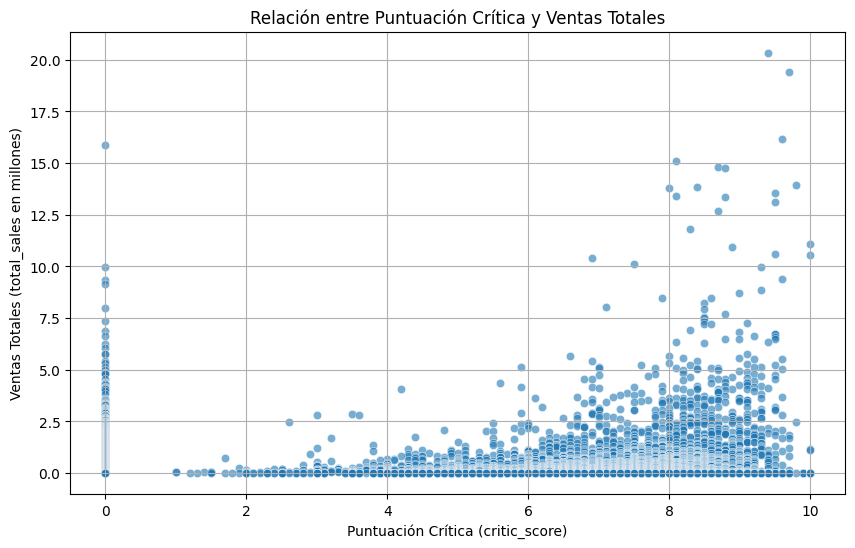

=== Coeficiente de Correlación ===
Coeficiente de Correlación de Pearson: 0.2813

=== Juegos con Puntuación Alta (>=90) y Ventas Bajas (<0.5M) ===
Empty DataFrame
Columns: [title, console, critic_score, total_sales]
Index: []

=== Juegos con Puntuación Baja (<=10) y Ventas Altas (>=30M) ===
Empty DataFrame
Columns: [title, console, critic_score, total_sales]
Index: []


In [12]:
# 1. Calcular Correlación
correlation = np.corrcoef(dfVideoJuegos['critic_score'], dfVideoJuegos['total_sales'])[0, 1]

# 2. Definir umbrales para Outliers (basados en la escala del dataset)
high_score_threshold = 90
low_sales_threshold = 0.5 # Menos de 0.5 millones de unidades

low_score_threshold = 10 
high_sales_threshold = 30 # Más de 30 millones de unidades

# Juegos de Puntuación Alta pero Ventas Bajas
high_score_low_sales = dfVideoJuegos[
    (dfVideoJuegos['critic_score'] >= high_score_threshold) & 
    (dfVideoJuegos['total_sales'] < low_sales_threshold)
]

# Juegos de Ventas Altas pero Puntuación Baja
low_score_high_sales = dfVideoJuegos[
    (dfVideoJuegos['critic_score'] <= low_score_threshold) & 
    (dfVideoJuegos['total_sales'] >= high_sales_threshold)
]


# 3. Generar Gráfico Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='critic_score', y='total_sales', data=dfVideoJuegos, alpha=0.6)
plt.title('Relación entre Puntuación Crítica y Ventas Totales')
plt.xlabel('Puntuación Crítica (critic_score)')
plt.ylabel('Ventas Totales (total_sales en millones)')
plt.grid(True)
plt.show()

# 4. Mostrar Resultados de Correlación y Outliers
print(f"=== Coeficiente de Correlación ===")
print(f"Coeficiente de Correlación de Pearson: {correlation:.4f}")

print("\n=== Juegos con Puntuación Alta (>=90) y Ventas Bajas (<0.5M) ===")
print(high_score_low_sales[['title', 'console', 'critic_score', 'total_sales']].head(5))

print("\n=== Juegos con Puntuación Baja (<=10) y Ventas Altas (>=30M) ===")
print(low_score_high_sales[['title', 'console', 'critic_score', 'total_sales']])

## 5 Análisis Auxiliar de Outliers (Numpy)
Uso de `np.nanpercentile` para detectar anomalías estadísticas:
1. Juegos con ventas extremas (Top 10%).
2. Juegos con discrepancia entre calidad y ventas (Joyas ocultas / Éxitos dudosos).

In [13]:
# --- 1. Definición de Umbrales Dinámicos con Numpy ---
# Usamos nanpercentile para ignorar valores vacíos automáticamente

# Umbrales para Ventas (Total Sales)
# El límite superior es el valor por encima del cual está el 10% de los juegos más vendidos
umbral_ventas_top = np.nanpercentile(dfVideoJuegos['total_sales'], 90)
umbral_ventas_bajas = np.nanpercentile(dfVideoJuegos['total_sales'], 10) 

# Umbrales para Crítica (Critic Score)
umbral_score_top = np.nanpercentile(dfVideoJuegos['critic_score'], 90)
umbral_score_bajo = np.nanpercentile(dfVideoJuegos['critic_score'], 10)

print(f"--- Estadísticas Calculadas ---")
print(f"Ventas Top 10% (> P90): {umbral_ventas_top:.2f} millones")
print(f"Score Top 10% (> P90):  {umbral_score_top:.1f} puntos")

--- Estadísticas Calculadas ---
Ventas Top 10% (> P90): 0.23 millones
Score Top 10% (> P90):  4.1 puntos
